In [1]:
# Import libraries
import os
import numpy as np
import pandas as pd

In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt

2025-06-25 23:19:36.022541: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-25 23:19:36.041426: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750889976.058247  304214 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750889976.063343  304214 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750889976.077273  304214 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [3]:
from Components.segmentation_utils import Losses, Metrics
from Components.model_optimisers import HnAdam

In [4]:
# Import custom definitions
from Components.definitions import *

print(f"Dataset path: {DATA_ROOT}")
print(f"Meta path: {Paths.metadata_csv}")
print(f"Mass training data path: {Paths.new_mass_train_csv}")
print(f"Mass test data path: {Paths.new_mass_test_csv}")
print(f"Mass train tensor path: {Paths.mass_train_tensor_dir}")
print(f"Mass test tensor path: {Paths.mass_test_tensor_dir}")

Dataset path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688
Meta path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/metadata.csv
Mass training data path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/new_mass_case_description_train_set.csv
Mass test data path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/new_mass_case_description_test_set.csv
Mass train tensor path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/mass_tensor/train
Mass test tensor path: /mnt/c/Users/lejam/Desktop/CBIS-DDSM/manifest-1748122768688/mass_tensor/test


# History

### Load history

In [5]:
history_df = pd.read_csv(os.path.join(DATA_ROOT, '9_1000_history.csv'))

history_df.tail()

,accuracy,dice_coef,jaccard_index,loss,val_accuracy,val_dice_coef,val_jaccard_index,val_loss,fold
995,0.999512,0.943660,0.908954,0.029990,0.999042,0.917869,0.878021,0.044326,49
996,0.999546,0.945934,0.912536,0.028826,0.999038,0.918313,0.878504,0.044508,49
997,0.999569,0.948853,0.917028,0.027295,0.999029,0.917127,0.876734,0.045265,49
998,0.999561,0.951348,0.920421,0.026022,0.999041,0.917595,0.877435,0.045069,49
999,0.999534,0.947493,0.915387,0.028006,0.999022,0.917250,0.877293,0.045296,49


In [6]:
history_df.loc[history_df[['val_dice_coef', 'val_jaccard_index']].idxmax().unique()]

,accuracy,dice_coef,jaccard_index,loss,val_accuracy,val_dice_coef,val_jaccard_index,val_loss,fold
943,0.999472,0.936823,0.89931,0.033495,0.999705,0.975576,0.955563,0.013706,47


### Visualise history

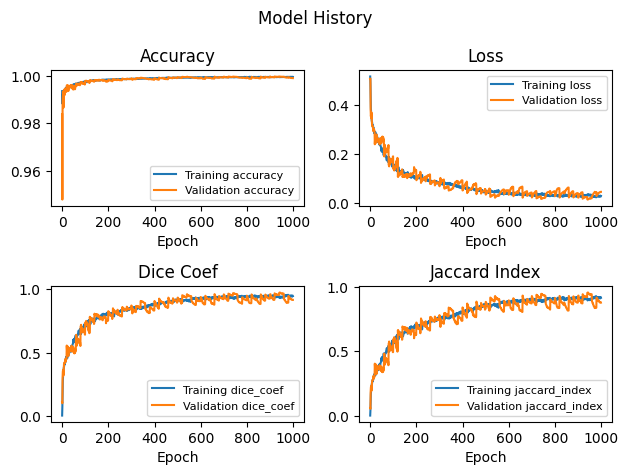

In [7]:
# Visualise model history
fig, ax = plt.subplots(2, 2)
fig.suptitle('Model History')
fontsize = 8

# Accuracy
ax[0,0].plot(history_df['accuracy'], label='Training accuracy')
ax[0,0].plot(history_df['val_accuracy'], label='Validation accuracy')
ax[0,0].set_title('Accuracy')
ax[0,0].set_xlabel('Epoch')
ax[0,0].legend(fontsize=fontsize)

# Loss
ax[0,1].plot(history_df['loss'], label='Training loss')
ax[0,1].plot(history_df['val_loss'], label='Validation loss')
ax[0,1].set_title('Loss')
ax[0,1].set_xlabel('Epoch')
ax[0,1].legend(fontsize=fontsize)

# Dice Coef
ax[1,0].plot(history_df['dice_coef'], label='Training dice_coef')
ax[1,0].plot(history_df['val_dice_coef'], label='Validation dice_coef')
ax[1,0].set_title('Dice Coef')
ax[1,0].set_xlabel('Epoch')
ax[1,0].legend(fontsize=fontsize)

# Dice Coef
ax[1,1].plot(history_df['jaccard_index'], label='Training jaccard_index')
ax[1,1].plot(history_df['val_jaccard_index'], label='Validation jaccard_index')
ax[1,1].set_title('Jaccard Index')
ax[1,1].set_xlabel('Epoch')
ax[1,1].legend(fontsize=fontsize)

plt.tight_layout()
plt.show()

# Model

In [8]:
# Load the saved model
loaded_model = tf.keras.models.load_model(
    os.path.join(DATA_ROOT, '9_1000_mass_model.keras'),
    custom_objects={
        'combined_loss': Losses.combined_loss,
        'dice_coef': Metrics.dice_coef,
        'jaccard_index': Metrics.jaccard_index
})

I0000 00:00:1750889982.058357  304214 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5564 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


### Model summary

In [9]:
loaded_model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │      1,792 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_19[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64, 64,    │          0 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     73,856 │ dropout_8[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_21[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32, 32,    │          0 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │    295,168 │ dropout_9[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_23[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 16, 16,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 16, 16,    │          0 │ max_pooling2d_6[… │
│ (Dropout)           │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ dropout_10[0][0]  │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ conv2d_25[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 8, 8, 512) │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 8, 8, 512) │          0 │ max_pooling2d_7[

 Total params: 103,540,041 (394.97 MB)

 Trainable params: 34,513,345 (131.66 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 69,026,696 (263.32 MB)

### Evaluation

In [10]:
test_images = tf.data.Dataset.load(Paths.mass_test_tensor_dir)
for x, y in test_images.take(1):
    print(f"test image shape: {x.shape}, {y.shape}")

test_rows = len(test_images)
val_size = int(0.8 * test_rows)
test_size = test_rows - val_size
BATCH_SIZE = 8

test_batches = (
    test_images
    .skip(val_size)
    .take(test_size)
    .batch(BATCH_SIZE)
)

test image shape: (128, 128, 3), (128, 128, 1)


2025-06-25 23:19:50.097879: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [11]:
evaluations = loaded_model.evaluate(test_batches)

I0000 00:00:1750889991.103710  304374 cuda_dnn.cc:529] Loaded cuDNN version 91002


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.9996 - dice_coef: 0.9404 - jaccard_index: 0.9061 - loss: 0.0312


In [12]:
print("Evaluation with test dataset:")
print(f"\tLoss: {evaluations[0]:.4f}")
print(f"\tAccuracy: {evaluations[1] * 100:.2f}%")

Evaluation with test dataset:
	Loss: 0.0195
	Accuracy: 99.98%


### Prediction

In [13]:
predictions = loaded_model.predict(test_batches)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


In [14]:
print(f"predictions size: {predictions.shape}")

predictions size: (76, 128, 128, 1)


In [15]:
from sklearn.metrics import classification_report

y_true_all = []
y_pred_all = []

for images, masks in test_batches:
    preds = loaded_model.predict(images)  # Shape: (batch, 128, 128, 1)

    # Apply threshold to predicted masks
    preds = (preds > 0.5).astype(np.uint8)

    # Flatten both prediction and mask to compare pixel-wise
    y_true_all.extend(masks.numpy().flatten().astype(np.uint8))
    y_pred_all.extend(preds.flatten())

# Use sklearn classification report
print(classification_report(y_true_all, y_pred_all))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step


2025-06-25 23:19:56.603088: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1238900
           1       0.98      0.97      0.98      6284

    accuracy                           1.00   1245184
   macro avg       0.99      0.99      0.99   1245184
weighted avg       1.00      1.00      1.00   1245184



In [16]:
def display(images):
    plt.figure(figsize=(7, 7))
    title = ["Input Image", "Ground Truth", "Predicted Mask"]
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.utils.array_to_img(images[i]))
        plt.axis("off")
    plt.show()
    
def create_mask(pred_mask):
    if False:
        mask = tf.math.argmax(pred_mask, axis=-1)
        mask = mask[..., tf.newaxis]
    else:  
        mask = tf.cast(pred_mask > 0.5, tf.uint8)
    
    print(np.unique(pred_mask), np.unique(mask),
          pred_mask.min(), pred_mask.max(),
          pred_mask.shape, mask.shape)
    return mask[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[0.0000000e+00 1.1987301e-38 1.2134341e-38 ... 9.9999976e-01 9.9999988e-01
 1.0000000e+00] [0 1] 0.0 1.0 (8, 128, 128, 1) (8, 128, 128, 1)


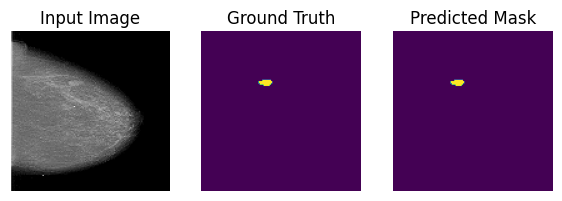

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
[0.0000000e+00 1.1922725e-38 1.2298659e-38 ... 9.9999976e-01 9.9999988e-01
 1.0000000e+00] [0 1] 0.0 1.0 (8, 128, 128, 1) (8, 128, 128, 1)


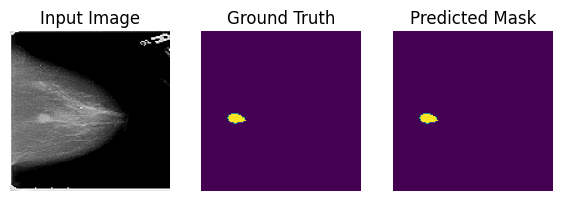

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
[0.0000000e+00 1.1864288e-38 1.1978067e-38 ... 9.9999976e-01 9.9999988e-01
 1.0000000e+00] [0 1] 0.0 1.0 (8, 128, 128, 1) (8, 128, 128, 1)


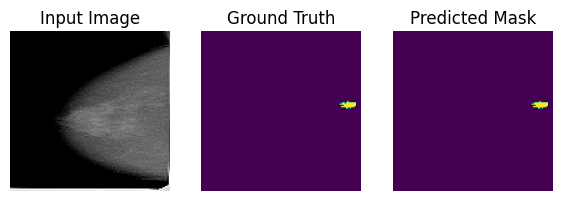

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
[0.0000000e+00 1.1901367e-38 1.2016144e-38 ... 9.9999976e-01 9.9999988e-01
 1.0000000e+00] [0 1] 0.0 1.0 (8, 128, 128, 1) (8, 128, 128, 1)


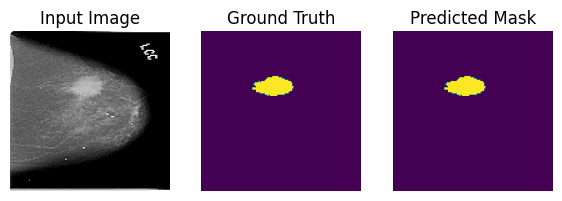

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[0.0000000e+00 1.1865555e-38 1.2134341e-38 ... 9.9999976e-01 9.9999988e-01
 1.0000000e+00] [0 1] 0.0 1.0 (8, 128, 128, 1) (8, 128, 128, 1)


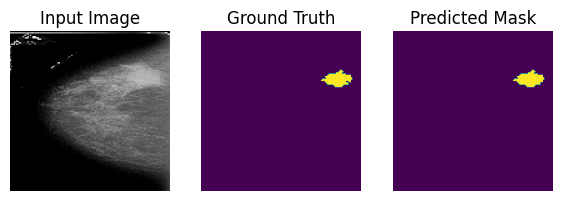

In [17]:
image_number = 5
if True:
    for image, mask in test_batches.take(image_number):
        pred_mask = loaded_model.predict(image)
        true_mask = mask[0] # tf.expand_dims(mask[0], axis=-1)
        
        display([image[0], true_mask, create_mask(pred_mask)])
else:
    # Shuffle and take 3 random batches
    for image, mask in test_batches.shuffle(1000).take(image_number):
        pred_mask = loaded_model.predict(image)
        true_mask = mask[0]
        display([image[0], true_mask, create_mask(pred_mask)])